### 1. Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 2. Load Data

In [6]:
df = pd.read_csv('../data/application_train.csv')

print("Shape:", df.shape)
df.head()

Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [137]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [138]:
df.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

### 3. Identify Column Types

In [139]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print(f"Numeric columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")

Numeric columns: 106
Categorical columns: 16


C:\Users\humza\AppData\Local\Temp\ipykernel_14624\950952689.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


### 4. Missing Data Report

In [140]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values(by='missing_pct', ascending=False)

missing_df.head(20)

,missing_count,missing_pct
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


In [141]:
# Features with >50% missing
high_missing = missing_df[missing_df['missing_pct'] > 50]
print("Columns with >50% missing:", len(high_missing))

Columns with >50% missing: 41


#### Several features have over 50% missing values, indicating potential data quality issues. These features may need to be dropped or carefully imputed in later preprocessing steps.

### 5. Target Distribution (Class Imbalance)

In [142]:
target_dist = df['TARGET'].value_counts(normalize=True)
print(target_dist)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


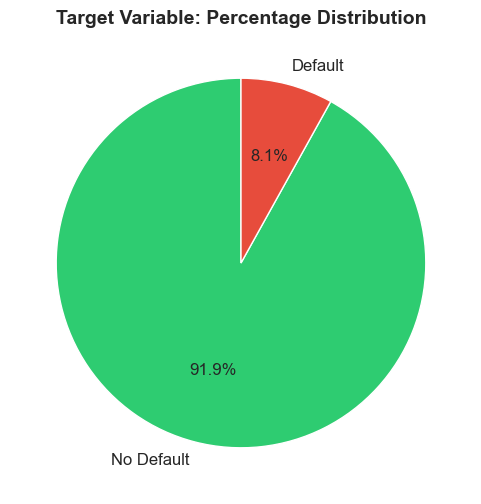


📊 Interpretation:
The dataset has approximately 8.1% default rate, which is realistic for consumer lending.
This imbalance will require special handling during model training.


In [143]:
import matplotlib.pyplot as plt

# Define colors
colors = ['#2ecc71', '#e74c3c']

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(target_dist.values, 
        labels=['No Default', 'Default'], 
        autopct='%1.1f%%', 
        colors=colors, 
        startangle=90, 
        textprops={'fontsize': 12})
plt.title('Target Variable: Percentage Distribution', fontsize=14, fontweight='bold')
plt.show()

# Optional interpretation
print("\n📊 Interpretation:")
print(f"The dataset has approximately {target_dist[1]:.1%} default rate, which is realistic for consumer lending.")
print("This imbalance will require special handling during model training.")

### 6. Default Rate by Segments

In [144]:
def default_rate_by_feature(feature):
    return df.groupby(feature)['TARGET'].mean().sort_values(ascending=False)

In [145]:
features = [
    'NAME_CONTRACT_TYPE',
    'NAME_INCOME_TYPE',
    'OCCUPATION_TYPE',
    'ORGANIZATION_TYPE'
]

for col in features:
    print(f"\nDefault Rate by {col}")
    print(default_rate_by_feature(col).head(10))


Default Rate by NAME_CONTRACT_TYPE
NAME_CONTRACT_TYPE
Cash loans         0.083459
Revolving loans    0.054783
Name: TARGET, dtype: float64

Default Rate by NAME_INCOME_TYPE
NAME_INCOME_TYPE
Maternity leave         0.400000
Unemployed              0.363636
Working                 0.095885
Commercial associate    0.074843
State servant           0.057550
Pensioner               0.053864
Businessman             0.000000
Student                 0.000000
Name: TARGET, dtype: float64

Default Rate by OCCUPATION_TYPE
OCCUPATION_TYPE
Low-skill Laborers      0.171524
Drivers                 0.113261
Waiters/barmen staff    0.112760
Security staff          0.107424
Laborers                0.105788
Cooking staff           0.104440
Sales staff             0.096318
Cleaning staff          0.096067
Realty agents           0.078562
Secretaries             0.070498
Name: TARGET, dtype: float64

Default Rate by ORGANIZATION_TYPE
ORGANIZATION_TYPE
Transport: type 3    0.157540
Industry: type 13    0.13

### 7. Feature Distributions (2x3 Grid)

In [152]:
# Convert age
df['age'] = (df['DAYS_BIRTH']) / 365

# Fix sentinel
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

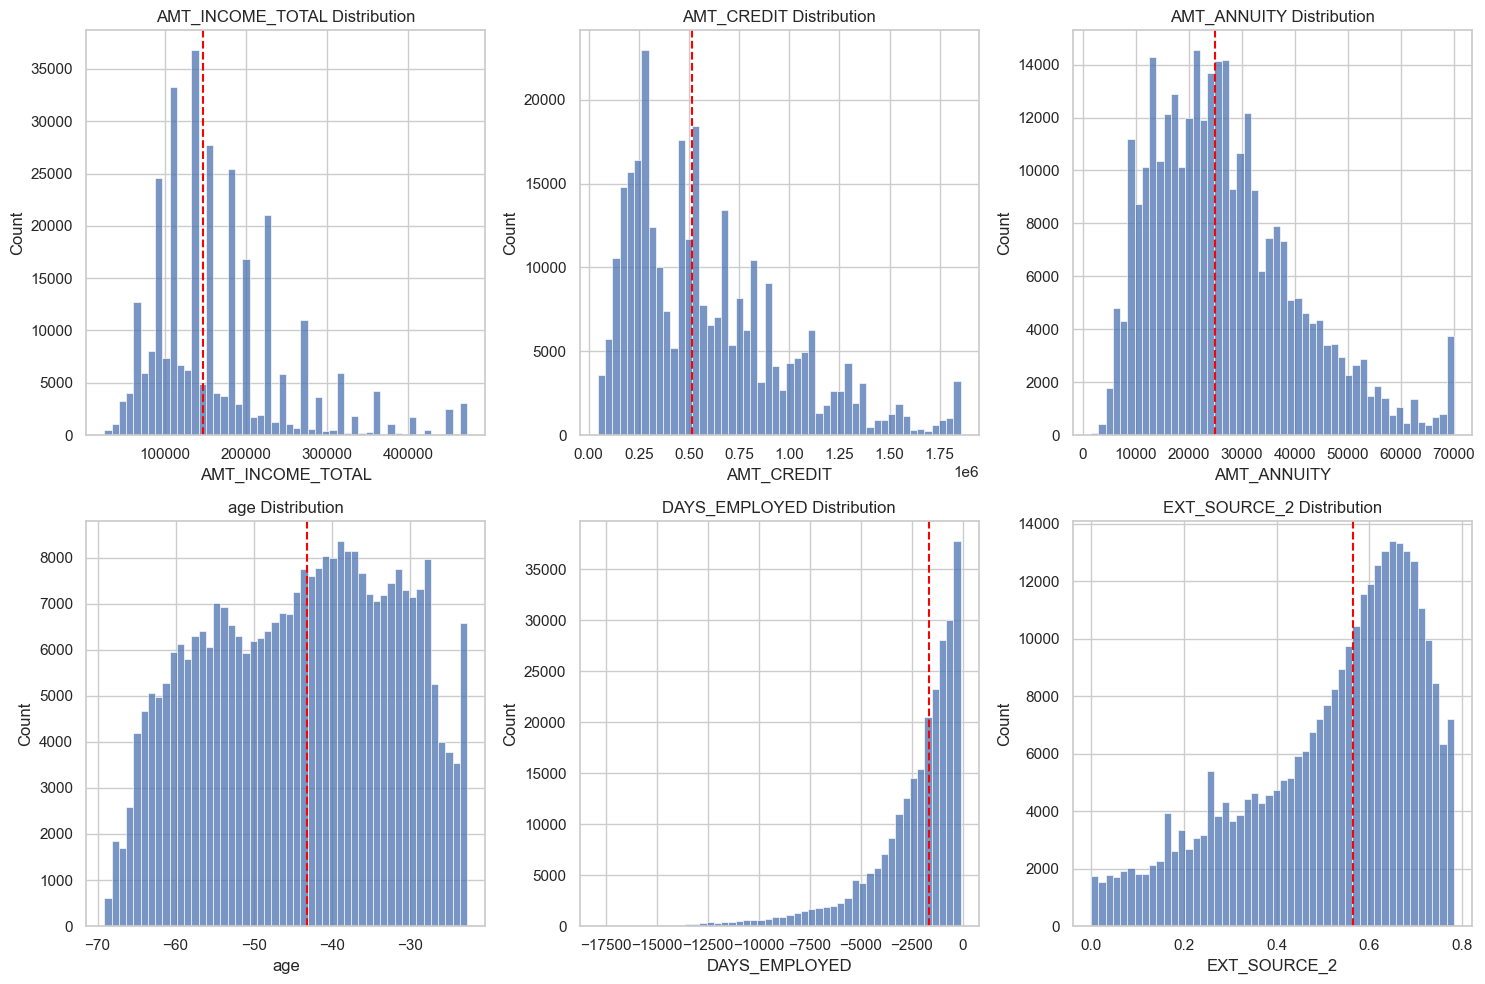


📊 Key Observations:
1. Income and credit amounts are right-skewed (long tail to the right)
2. Age distribution looks normal, centered around 40-45 years
3. Days employed average around 2000 days, but has a long tail (some very long employment durations)
4. EXT_SOURCE_2 is mostly between 0 and 1, with a peak around 0.7


In [154]:
features = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'age',
    'DAYS_EMPLOYED',
    'EXT_SOURCE_2'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, col in enumerate(features):
    ax = axes[i // 3, i % 3]
    
    data = df[col].clip(upper=df[col].quantile(0.99))
    
    sns.histplot(data, bins=50, ax=ax)
    ax.axvline(data.median(), color='red', linestyle='--')
    
    ax.set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

print("\n📊 Key Observations:")
print("1. Income and credit amounts are right-skewed (long tail to the right)")
print("2. Age distribution looks normal, centered around 40-45 years")
print("3. Days employed average around 2000 days, but has a long tail (some very long employment durations)")
print("4. EXT_SOURCE_2 is mostly between 0 and 1, with a peak around 0.7")

### 8. Correlation Heatmap (Top 15)

In [148]:
# Calculate correlations with TARGET

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

correlations = df[numeric_cols].corr()['TARGET'].sort_values(ascending=False)

# Remove TARGET itself and get top 15 (excluding TARGET)
top_correlations = correlations[correlations.index != 'TARGET'].head(15)

print("=" * 80)
print("TOP 15 FEATURES MOST CORRELATED WITH DEFAULT RISK")
print("=" * 80)
for feature, corr in top_correlations.items():
    direction = "↑ Higher" if corr > 0 else "↓ Lower"
    print(f"{feature:40s} {corr:6.3f}  ({direction} = More Default Risk)")

TOP 15 FEATURES MOST CORRELATED WITH DEFAULT RISK
age                                       0.078  (↑ Higher = More Default Risk)
DAYS_BIRTH                                0.078  (↑ Higher = More Default Risk)
DAYS_EMPLOYED                             0.075  (↑ Higher = More Default Risk)
REGION_RATING_CLIENT_W_CITY               0.061  (↑ Higher = More Default Risk)
REGION_RATING_CLIENT                      0.059  (↑ Higher = More Default Risk)
DAYS_LAST_PHONE_CHANGE                    0.055  (↑ Higher = More Default Risk)
DAYS_ID_PUBLISH                           0.051  (↑ Higher = More Default Risk)
REG_CITY_NOT_WORK_CITY                    0.051  (↑ Higher = More Default Risk)
FLAG_EMP_PHONE                            0.046  (↑ Higher = More Default Risk)
REG_CITY_NOT_LIVE_CITY                    0.044  (↑ Higher = More Default Risk)
FLAG_DOCUMENT_3                           0.044  (↑ Higher = More Default Risk)
DAYS_REGISTRATION                         0.042  (↑ Higher = More Defa

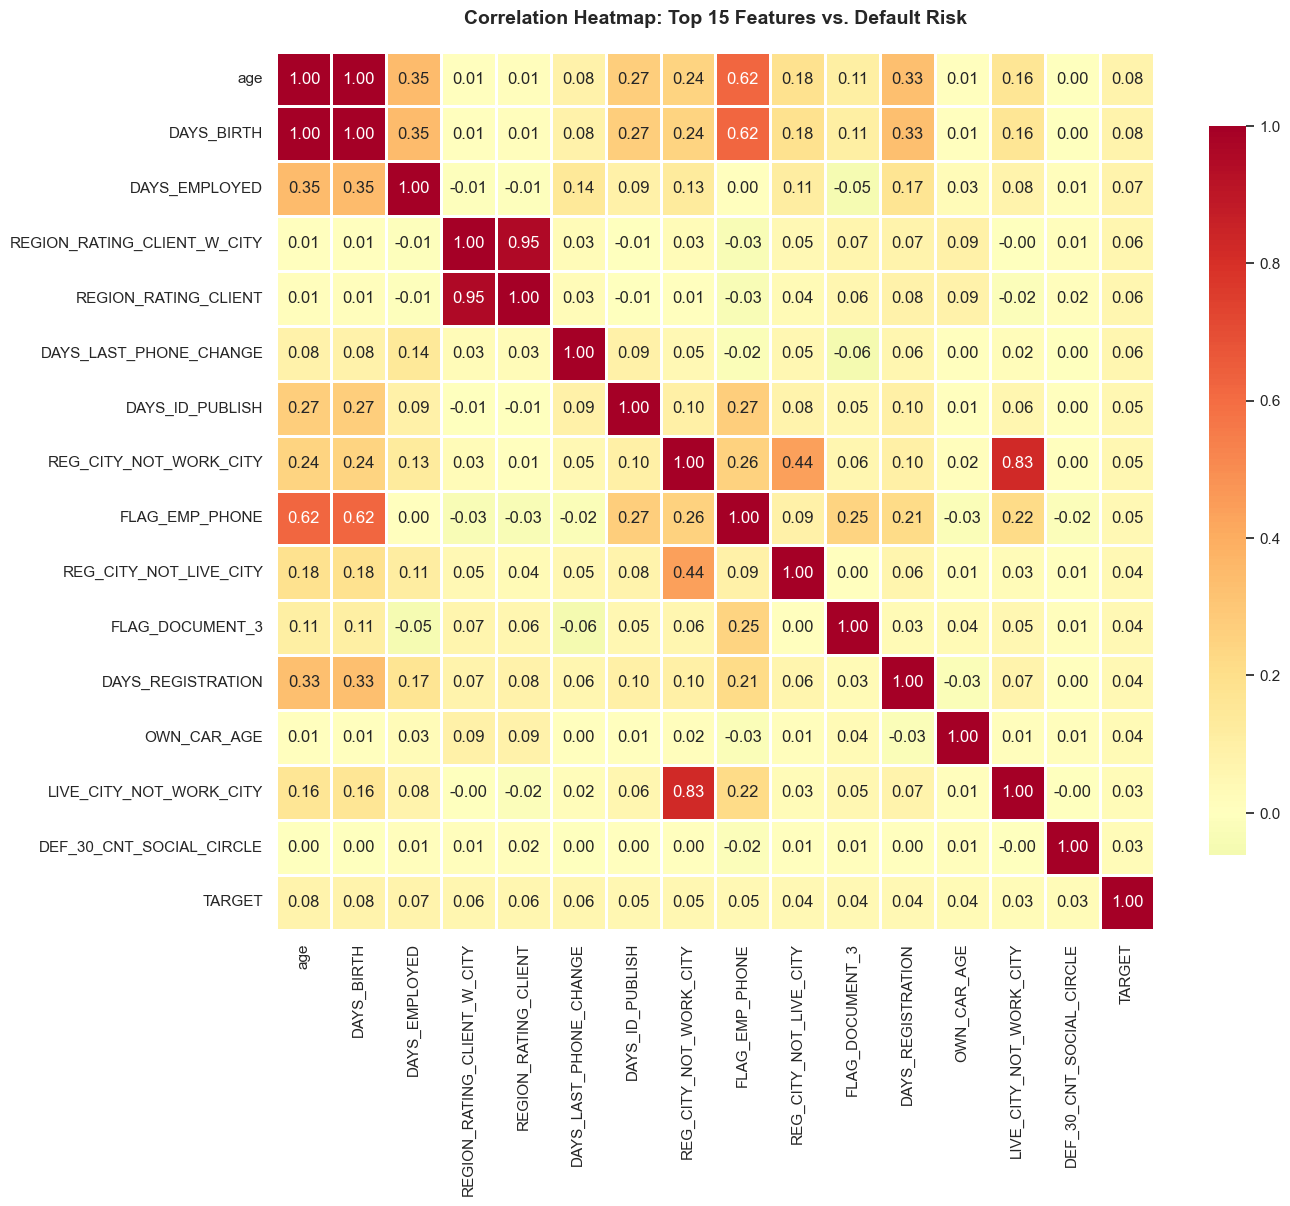


📊 Key Insights:
1. EXT_SOURCE features (external credit bureau scores) show strong negative correlation
   → Lower external credit scores = Higher default risk
2. Look for features that are correlated with each other (multicollinearity)
3. These features will be our starting point for feature engineering


In [149]:
# Create correlation heatmap of top features
top_features = top_correlations.index.tolist() + ['TARGET']
correlation_matrix = df[top_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Top 15 Features vs. Default Risk', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n📊 Key Insights:")
print("1. EXT_SOURCE features (external credit bureau scores) show strong negative correlation")
print("   → Lower external credit scores = Higher default risk")
print("2. Look for features that are correlated with each other (multicollinearity)")
print("3. These features will be our starting point for feature engineering")

### 9. Bureau Data Integration

In [150]:
bureau = pd.read_csv('../data/bureau.csv')

bureau_counts = bureau.groupby('SK_ID_CURR').size().reset_index(name='num_bureau_records')

df = df.merge(bureau_counts, on='SK_ID_CURR', how='left')

df['num_bureau_records'] = df['num_bureau_records'].fillna(0)

### 10. Relationship with Default

C:\Users\humza\AppData\Local\Temp\ipykernel_14624\1951401418.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['bureau_bin'] = pd.cut(df['num_bureau_records'],



=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
DEFAULT RATE BY NUMBER OF BUREAU RECORDS
            count  defaults  default_rate
bureau_bin                               
0           44020      4457         10.12
1           36072      3098          8.59
2           35635      2784          7.81
3-5         86883      6430          7.40
6-10        72624      5415          7.46
11+         32276      2641          8.18


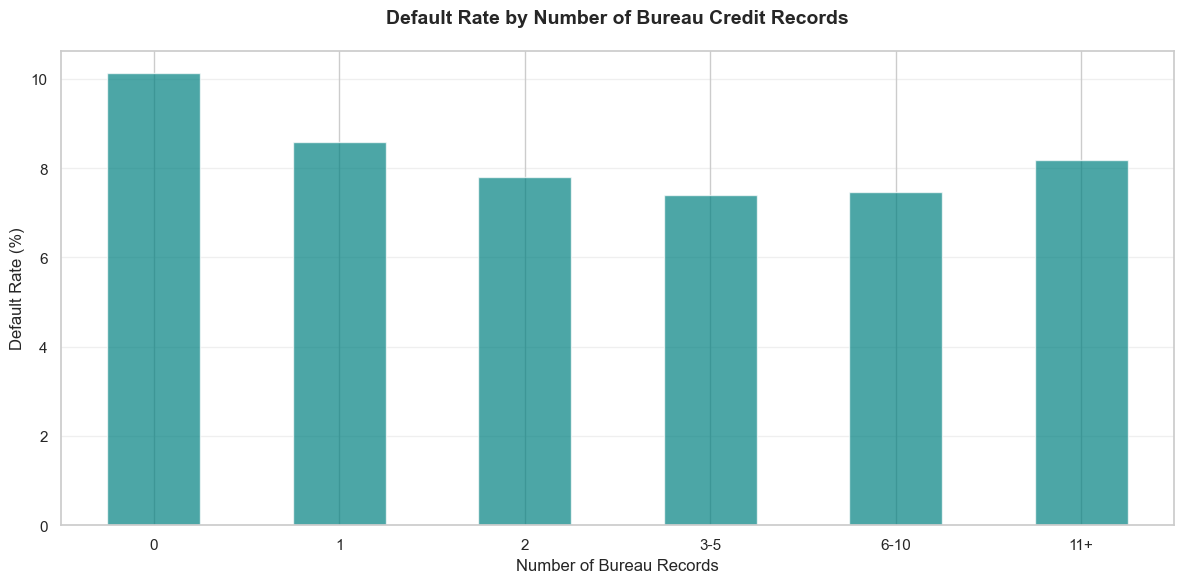


📊 Interpretation:
The relationship between bureau records and default rate reveals credit behavior patterns.
This feature will be valuable for our predictive model.


In [151]:
# Analyze relationship between bureau records and default
if 'num_bureau_records' in df.columns:
    # Create bins for bureau record counts
    df['bureau_bin'] = pd.cut(df['num_bureau_records'], 
                               bins=[-0.1, 0, 1, 2, 5, 10, 100],
                               labels=['0', '1', '2', '3-5', '6-10', '11+'])
    
    # Compute default rate by bureau record count
    bureau_default = df.groupby('bureau_bin').agg(
        count=('TARGET', 'count'),
        defaults=('TARGET', 'sum')
    )
    bureau_default['default_rate'] = (bureau_default['defaults'] / bureau_default['count'] * 100).round(2)
    
    print("\n=" * 80)
    print("DEFAULT RATE BY NUMBER OF BUREAU RECORDS")
    print("=" * 80)
    print(bureau_default.to_string())
    
    # Visualize
    plt.figure(figsize=(12, 6))
    bureau_default['default_rate'].plot(kind='bar', color='teal', alpha=0.7)
    plt.title('Default Rate by Number of Bureau Credit Records', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Number of Bureau Records', fontsize=12)
    plt.ylabel('Default Rate (%)', fontsize=12)
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Interpretation:")
    print("The relationship between bureau records and default rate reveals credit behavior patterns.")
    print("This feature will be valuable for our predictive model.")